# HW12: PCA

In [27]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd  
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import het_white
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import KFold, RepeatedKFold, RepeatedStratifiedKFold

from statsmodels.stats.outliers_influence import\
variance_inflation_factor, OLSInfluence

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, cross_val_score

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

from tqdm.notebook import tqdm

P_THRESH = 0.01

In [30]:
%load_ext pycodestyle_magic

In [2]:
from sklearn.datasets import load_boston

def load_housing_data_frame(verbose=True):
    raw = load_boston()
    data_frame = pd.DataFrame(raw.data, columns=raw.feature_names)
    data_frame['PRICE'] = raw.target
    if verbose:
        print(raw.DESCR)
    return data_frame

## Loading the data

In [3]:
df = load_housing_data_frame()

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Looking for correlations

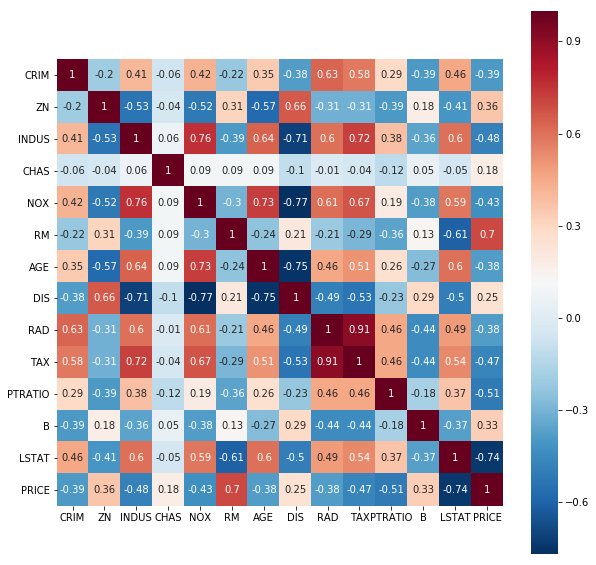

In [5]:
plt.figure(figsize=(10,10))
correlation_matrix = df.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True,
            cmap = 'RdBu_r', square=True)

## Most promising features

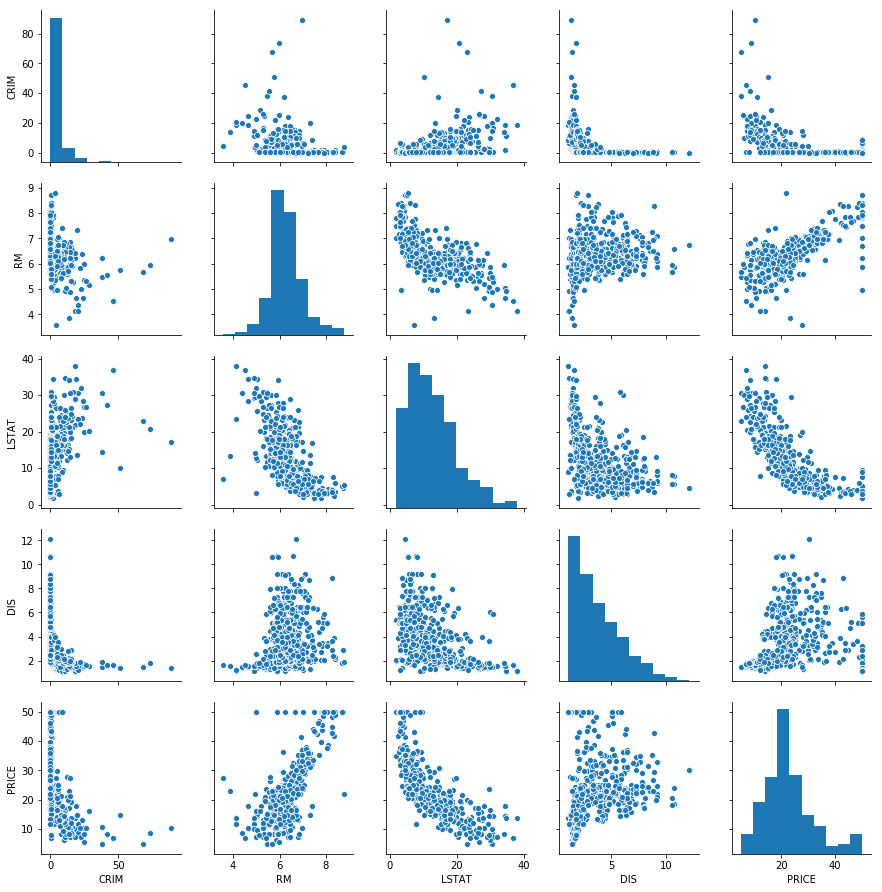

In [6]:
sns.pairplot(df, vars=['CRIM', 'RM',
                       'LSTAT', 'DIS',
                       'PRICE'])

### Taking some logarithms

In [6]:
df['dis_trans'] = np.log(df['DIS'])
df['crim_trans'] = -np.log(df['CRIM'])
df['lstat_trans'] = -np.log(df['LSTAT'])

df = df.drop(['LSTAT','DIS','CRIM'], axis=1)

### It turns out that it's better to take a square root of the price

In [7]:
df['PRICE'] = np.sqrt(df['PRICE'])

### Plotting the transformed features

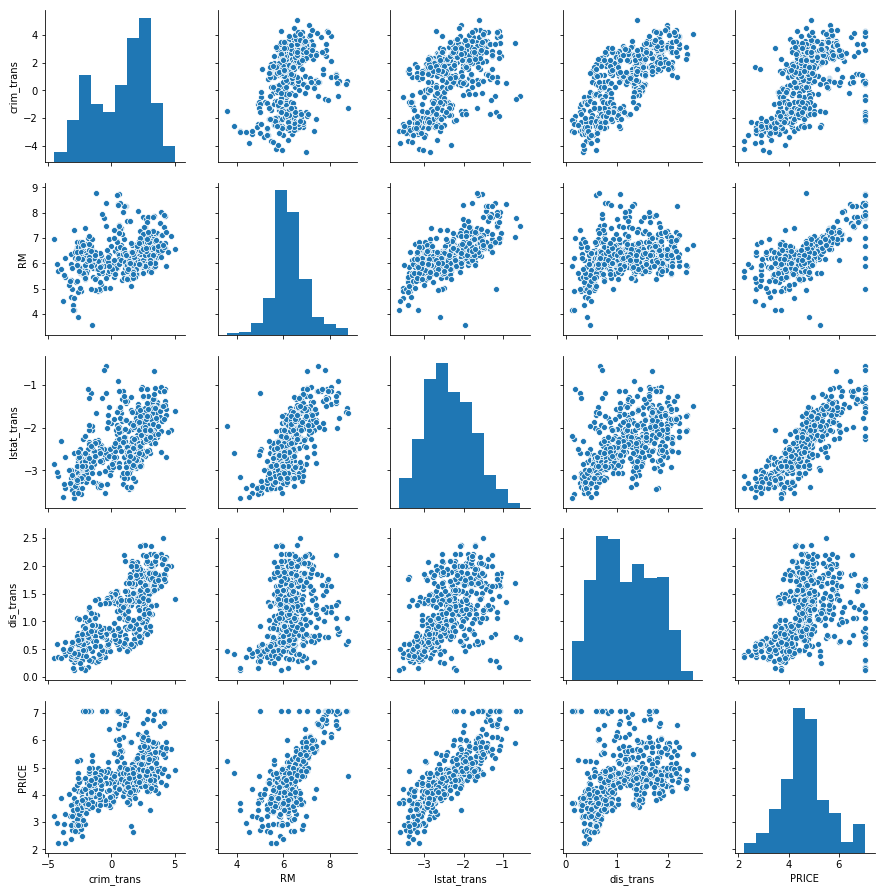

In [9]:
sns.pairplot(df, vars=['crim_trans', 'RM',
                       'lstat_trans','dis_trans',
                       'PRICE'])

In [8]:
features = df.columns[df.columns != 'PRICE']

In [9]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:, features],
                     df.loc[:, 'PRICE'],
                     test_size=0.3,
                     random_state=42)

Standardizing

In [10]:
sc = StandardScaler()

X_train_sc = pd.DataFrame(sc.fit_transform(X_train),
                          columns=X_train.columns,
                          index=X_train.index)

Model with raw data

In [11]:
model = OLS(y_train, sm.add_constant(X_train_sc)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     101.9
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          1.10e-108
Time:                        20:02:51   Log-Likelihood:                -203.38
No. Observations:                 354   AIC:                             434.8
Df Residuals:                     340   BIC:                             488.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.7023      0.023    201.734      0.000       4.656       4.748
ZN             -0.0297      0.035     -0.859      0.391      -0.098       0.038
INDUS           0.0213      0.046      0.460      0.646      -0.070       0.112
CHAS            0.0668      0.025      2.724      0.007       0.019       0.115
NOX            -0.1595      0.053     -3.023      0.003      -0.263      -0.056
RM              0.1704      0.034      4.984      0.000       0.103       0.238
AGE            -0.0043      0.042     -0.102      0.919      -0.087       0.079
RAD             0.1653      0.074      2.239      0.026       0.020       0.311
TAX            -0.1738      0.070     -2.497      0.013      -0.311      -0.037
PTRATIO        -0.1886      0.032     -5.871      0.000      -0.252      -0.125
B               0.1023      0.027      3.860      0.000       0.050       0.155
dis_trans      -0.2316      0.052     -4.470      0.000      -0.334      -0.130
crim_trans      0.0690      0.066      1.040      0.299      -0.062       0.200
lstat_trans     0.5647      0.041     13.882      0.000       0.485       0.645
==============================================================================
Omnibus:                       25.125   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               78.893
Skew:                           0.193   Prob(JB):                     7.39e-18
Kurtosis:                       5.280   Cond. No.                         11.0
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Check for outliers

(0, 0.01)

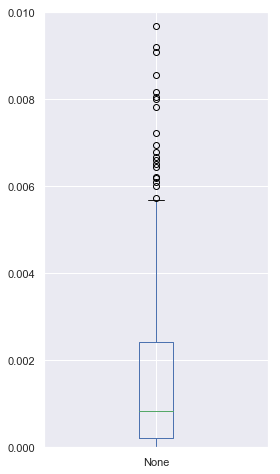

In [12]:
sns.set(rc={'figure.figsize': (4, 8)})
influence = OLSInfluence(model)
cooks_distance = influence.cooks_distance[0]
cooks_distance.plot.box()
plt.ylim((0, 0.01))

Getting rid of outliers

In [13]:
cooks_distance.describe()

count    3.540000e+02
mean     3.807266e-03
std      1.261567e-02
min      1.593973e-09
25%      2.080552e-04
50%      8.325101e-04
75%      2.417192e-03
max      1.548313e-01
dtype: float64

In [14]:
clean_index = cooks_distance[cooks_distance < 
                             cooks_distance.describe()['75%']].index

In [15]:
X_train_cl = X_train_sc.loc[clean_index, :]
y_train_cl = y_train[clean_index]

Refitting the model

In [16]:
model = OLS(y_train_cl, sm.add_constant(X_train_cl)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     242.6
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          7.00e-134
Time:                        20:03:22   Log-Likelihood:                 33.013
No. Observations:                 265   AIC:                            -38.03
Df Residuals:                     251   BIC:                             12.09
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.6784      0.014    338.052      0.000       4.651       4.706
ZN             -0.0120      0.020     -0.592      0.554      -0.052       0.028
INDUS           0.0324      0.025      1.284      0.200      -0.017       0.082
CHAS            0.0645      0.015      4.298      0.000       0.035       0.094
NOX            -0.1292      0.032     -4.084      0.000      -0.191      -0.067
RM              0.2863      0.027     10.695      0.000       0.234       0.339
AGE            -0.0615      0.028     -2.211      0.028      -0.116      -0.007
RAD            -0.0119      0.043     -0.274      0.784      -0.098       0.074
TAX            -0.1309      0.041     -3.160      0.002      -0.212      -0.049
PTRATIO        -0.1362      0.018     -7.426      0.000      -0.172      -0.100
B               0.1246      0.017      7.120      0.000       0.090       0.159
dis_trans      -0.1968      0.032     -6.189      0.000      -0.259      -0.134
crim_trans     -0.0646      0.040     -1.621      0.106      -0.143       0.014
lstat_trans     0.4506      0.031     14.381      0.000       0.389       0.512
==============================================================================
Omnibus:                        2.282   Durbin-Watson:                   2.146
Prob(Omnibus):                  0.319   Jarque-Bera (JB):                1.936
Skew:                           0.086   Prob(JB):                        0.380
Kurtosis:                       2.618   Cond. No.                         10.6
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Skipping the features with high p-values

In [17]:
features_new = [
    f 
    for f, p in zip([c for c in X_train_cl.columns if c != 'PRICE'],
                    model.pvalues[1:])
    if p < P_THRESH
]

In [18]:
model1 = OLS(y_train_cl, sm.add_constant(X_train_cl[features_new])).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     385.8
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          4.26e-138
Time:                        20:03:36   Log-Likelihood:                 27.966
No. Observations:                 265   AIC:                            -37.93
Df Residuals:                     256   BIC:                            -5.715
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.6786      0.014    336.161      0.000       4.651       4.706
CHAS            0.0676      0.015      4.513      0.000       0.038       0.097
NOX            -0.1174      0.029     -4.060      0.000      -0.174      -0.060
RM              0.2581      0.024     10.783      0.000       0.211       0.305
TAX            -0.0961      0.022     -4.392      0.000      -0.139      -0.053
PTRATIO        -0.1356      0.016     -8.225      0.000      -0.168      -0.103
B               0.1171      0.017      6.730      0.000       0.083       0.151
dis_trans      -0.1943      0.027     -7.211      0.000      -0.247      -0.141
lstat_trans     0.4759      0.028     16.946      0.000       0.421       0.531
==============================================================================
Omnibus:                        2.506   Durbin-Watson:                   2.132
Prob(Omnibus):                  0.286   Jarque-Bera (JB):                2.278
Skew:                           0.141   Prob(JB):                        0.320
Kurtosis:                       2.644   Cond. No.                         4.92
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Residues distribution

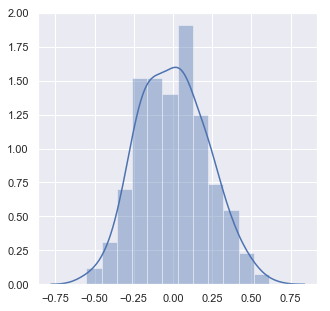

In [19]:
sns.set(rc={'figure.figsize': (5, 5)})
sns.distplot(model1.resid)

Heteroskedasticity

In [20]:
het_white(model1.resid, sm.add_constant(X_train_cl[features_new]))

(62.843173101538305,
 0.025730433194962585,
 1.5976936585045234,
 0.016185433901700932)

CV scores on train

In [21]:
kf = RepeatedKFold(n_repeats=30, n_splits=5, random_state=42)

In [22]:
score = cross_val_score(LinearRegression(), X_train_cl[features_new],
                        y_train_cl, scoring='r2',
                        cv=kf.split(X_train_cl[features_new], y_train_cl))
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

mean: 0.9137633055784325
std: 0.021993060851003818


Test score

In [23]:
X_test_sc = pd.DataFrame(sc.transform(X_test),
                         columns=X_test.columns,
                         index=X_test.index)

In [24]:
test_score0 = r2_score(y_test, model1.predict(sm.add_constant(X_test_sc[features_new])))
test_score0

0.7639339756287804

## PCA

In [25]:
# number of PCA components
n_comp = np.arange(2, len(features_new)+1, 1)

In [26]:
folds = list(kf.split(X_train_cl[features_new], y_train_cl))

Evaluating the CV scores of different PCA transforms

In [37]:
np.random.seed(42)

r2_scores = {}

for n in tqdm(n_comp):

    rs = np.zeros(len(folds))

    for idx, (train_index, test_index) in enumerate((folds), start=0):

        X_train2 = X_train_sc[features_new].iloc[train_index, :]
        y_train2 = y_train.iloc[train_index]
        X_test2 = X_train_sc[features_new].iloc[test_index, :]
        y_test2 = y_train.iloc[test_index]

        pca_transform = PCA(n_components=n)

        X_train2_f = X_train2.copy()
        X_train2_f = pca_transform.fit_transform(X_train2_f)
        y_train2_f = y_train2.copy()

        model = OLS(y_train2_f, sm.add_constant(X_train2_f)).fit()

        X_test2_f = X_test2.copy()
        X_test2_f = pca_transform.transform(X_test2_f)

        y_test2_f = y_test2.copy()

        rs[idx] = r2_score(y_test2_f,
                           model.predict(sm.add_constant(X_test2_f)))

    r2_scores[n] = np.mean(rs), np.std(rs)

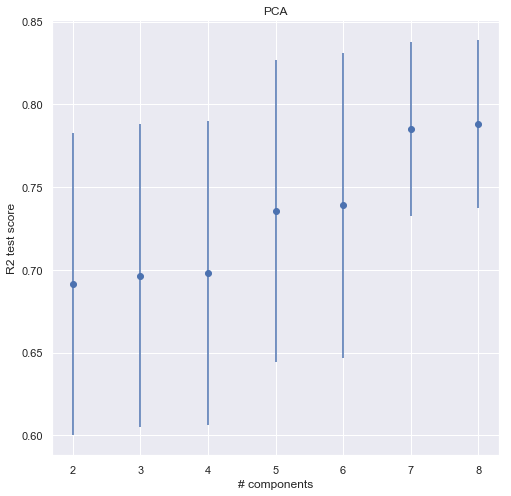

In [36]:
plt.figure(figsize=(8, 8))
plt.title('PCA')

plt.errorbar(r2_scores.keys(),
             np.array(list(r2_scores.values()))[:, 0],
             yerr=np.array(list(r2_scores.values()))[:, 1],
             fmt='o')
plt.xlabel('# components')
plt.ylabel('R2 test score')
plt.show()

Trying to run the model on the transformed data

In [38]:
BEST_NUMBER = 7

In [39]:
pca_transform = PCA(n_components=BEST_NUMBER)

In [40]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:, features_new],
                     df.loc[:, 'PRICE'],
                     test_size=0.3,
                     random_state=42)

In [41]:
X_train_cl = X_train.loc[clean_index, :]
y_train_cl = y_train[clean_index]

In [42]:
X_train_sc = pd.DataFrame(sc.fit_transform(X_train_cl),
                          columns=X_train.columns,
                          index=X_train_cl.index)

In [43]:
X_train_pca = pca_transform.fit_transform(X_train_sc)

In [44]:
model = OLS(y_train_cl,sm.add_constant(X_train_pca)).fit()

In [45]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     399.2
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          3.83e-134
Time:                        20:08:02   Log-Likelihood:                 15.380
No. Observations:                 265   AIC:                            -14.76
Df Residuals:                     257   BIC:                             13.88
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6869      0.014    329.074      0.000       4.659       4.715
x1            -0.3444      0.008    -45.325      0.000      -0.359      -0.329
x2             0.2871      0.012     23.005      0.000       0.262       0.312
x3            -0.0394      0.015     -2.662      0.008      -0.068      -0.010
x4             0.0019      0.015      0.128      0.898      -0.028       0.032
x5            -0.2078      0.017    -12.108      0.000      -0.242      -0.174
x6             0.1170      0.024      4.936      0.000       0.070       0.164
x7             0.1878      0.033      5.752      0.000       0.123       0.252
==============================================================================
Omnibus:                        3.353   Durbin-Watson:                   2.099
Prob(Omnibus):                  0.187   Jarque-Bera (JB):                3.110
Skew:                           0.198   Prob(JB):                        0.211
Kurtosis:                       2.646   Cond. No.                         4.30
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:
X_train_pca1 = X_train_pca[:, (model.pvalues.values < P_THRESH)[1:]]

In [47]:
model1 = OLS(y_train_cl,sm.add_constant(X_train_pca1)).fit()

In [48]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     467.6
Date:                Wed, 29 Jan 2020   Prob (F-statistic):          1.71e-135
Time:                        20:08:12   Log-Likelihood:                 15.371
No. Observations:                 265   AIC:                            -16.74
Df Residuals:                     258   BIC:                             8.316
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6869      0.014    329.703      0.000       4.659       4.715
x1            -0.3444      0.008    -45.412      0.000      -0.359      -0.329
x2             0.2871      0.012     23.049      0.000       0.263       0.312
x3            -0.0394      0.015     -2.667      0.008      -0.068      -0.010
x4            -0.2078      0.017    -12.131      0.000      -0.241      -0.174
x5             0.1170      0.024      4.946      0.000       0.070       0.164
x6             0.1878      0.033      5.763      0.000       0.124       0.252
==============================================================================
Omnibus:                        3.425   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.180   Jarque-Bera (JB):                3.149
Skew:                           0.197   Prob(JB):                        0.207
Kurtosis:                       2.639   Cond. No.                         4.30
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Heteroskedasticity test

In [49]:
het_white(model1.resid, sm.add_constant(X_train_pca1))

(47.01692087738271,
 0.009864632969235627,
 1.8932849509152796,
 0.006461537757358306)

Residues

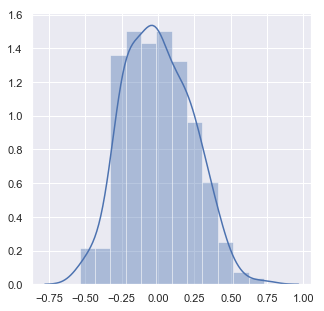

In [50]:
sns.set(rc={'figure.figsize': (5, 5)})
sns.distplot(model1.resid)

CV on train

In [51]:
score_pca = cross_val_score(LinearRegression(),
                            X_train_pca1, y_train_cl,
                            scoring='r2',
                            cv=kf.split(X_train_pca1,y_train_cl))

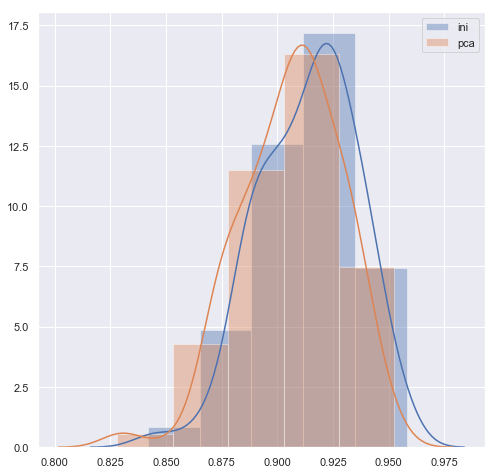

In [52]:
sns.set(rc={'figure.figsize': (8, 8)})
sns.distplot(score,label='ini', bins=5,
             norm_hist=True)
sns.distplot(score_pca, label='pca', bins=5,
             norm_hist=True)
plt.legend()

Test score

In [53]:
X_test_sc = pd.DataFrame(sc.transform(X_test),
                         columns=X_test.columns,
                         index=X_test.index)

In [54]:
X_test_pca = pca_transform.transform(X_test_sc)

In [55]:
X_test_pca1 = X_test_pca[:, (model.pvalues.values < P_THRESH)[1:]]

In [56]:
test_score = r2_score(y_test,
                      model1.predict(sm.add_constant(X_test_pca1)))

Comparison with the value obtained without PCA

In [57]:
test_score-test_score0

-0.025510515952024138

__It seems that PCA transform is not beneficial for this particular dataset__